In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
!pip install kaggle --quiet

In [ ]:
from google.colab import files
files.upload() 

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vaishu1997","key":"c8860ab0eef868aa5405b38c56e7315f"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [49]:
!kaggle datasets download -d prasad22/healthcare-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
License(s): CC0-1.0
  0% 0.00/2.91M [00:00<?, ?B/s]
100% 2.91M/2.91M [00:00<00:00, 152MB/s]


In [50]:
# Load dataset
df = pd.read_csv("healthcare_dataset.csv")
print("Original Dataset Preview:\n", df.head())
print("Original Dataset Shape:", df.shape)
print("Original Dataset Columns:", df.columns.tolist())

Original Dataset Preview:
             Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medicati

In [ ]:
#Data Cleaning
text_columns = ["Name", "Gender", "Blood Type", "Medical Condition", "Doctor", "Hospital",
                "Insurance Provider", "Admission Type", "Medication", "Test Results"]

df[text_columns] = df[text_columns].apply(lambda x: x.str.lower())

In [ ]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], errors='coerce')
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], errors='coerce')

In [53]:
print("Number of Rows:", len(df))

Number of Rows: 55500


In [ ]:
df.drop_duplicates(inplace=True)

In [55]:
print("Number of Rows:", len(df))

Number of Rows: 54966


In [ ]:
mean_billing_amount = df[df["Billing Amount"] >= 0]["Billing Amount"].mean()
df["Billing Amount"] = df["Billing Amount"].apply(lambda x: mean_billing_amount if x < 0 else x)


In [ ]:
billing_amount_tensor = torch.tensor(df["Billing Amount"].values, dtype=torch.float32)
rounded_billing_amount = torch.round(billing_amount_tensor)

In [ ]:
df["Billing Amount"] = rounded_billing_amount.numpy()

In [ ]:
#  Missing Values
print("\nMissing Values Count:")
missing_data = df.isnull().sum()
print(missing_data)
print(f"Total missing values: {missing_data.sum()}")


Missing Values Count:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64
Total missing values: 0


In [60]:
print("DataSet After DataCleaning:\n", df.head())

DataSet After DataCleaning:
             Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  bobby jackson   30    male         b-            cancer        2024-01-31   
1   leslie terry   62    male         a+           obesity        2019-08-20   
2    danny smith   76  female         a-           obesity        2022-09-22   
3   andrew watts   28  female         o+          diabetes        2020-11-18   
4  adrienne bell   43  female        ab+            cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     matthew smith             sons and miller         blue cross   
1   samantha davies                     kim inc           medicare   
2  tiffany mitchell                    cook plc              aetna   
3       kevin wells  hernandez rogers and vang,           medicare   
4    kathleen hanna                 white-white              aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medica

In [ ]:
# PART 2. Data Integration
df["Hospital Stay Duration"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
df["Hospital Stay Duration"] = df["Hospital Stay Duration"].apply(lambda x: max(x, 0))
print(df[["Date of Admission", "Discharge Date", "Hospital Stay Duration"]].head())
df["Age Group"] = pd.cut(df["Age"], bins=[0, 18, 50, 100], labels=[0, 1, 2]).astype(int)
print(df[["Age", "Age Group"]].head())

  Date of Admission Discharge Date  Hospital Stay Duration
0        2024-01-31     2024-02-02                       2
1        2019-08-20     2019-08-26                       6
2        2022-09-22     2022-10-07                      15
3        2020-11-18     2020-12-18                      30
4        2022-09-19     2022-10-09                      20
   Age  Age Group
0   30          1
1   62          2
2   76          2
3   28          1
4   43          1


In [ ]:
# Outlier Detection using IQR
def detect_outliers_iqr(data, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

numeric_columns = ['Age', 'Billing Amount', 'Room Number','Hospital Stay Duration','Age Group']
outliers = {col: detect_outliers_iqr(df, col) for col in numeric_columns}

#  detected outliers
for col, outlier_df in outliers.items():
    print(f"\nOutliers in {col}:")
    print(outlier_df)



Outliers in Age:
Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Hospital Stay Duration, Age Group]
Index: []

Outliers in Billing Amount:
Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Hospital Stay Duration, Age Group]
Index: []

Outliers in Room Number:
Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Hospital Stay Duration, Age Group]
Index: []

Outliers in Hospital Stay Duration:
Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, 

In [ ]:
# PART 3: DATA SUMMARIZATION
print("\nDATA SUMMARIZATION")
print("\nStatistical Summary:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)


==== DATA SUMMARIZATION ====

Statistical Summary:
                Age              Date of Admission  Billing Amount  \
count  54966.000000                          54966    54966.000000   
mean      51.535185  2021-11-01 17:35:29.505512448    25594.634766   
min       13.000000            2019-05-08 00:00:00        9.000000   
25%       35.000000            2020-07-28 00:00:00    13325.750000   
50%       52.000000            2021-11-02 00:00:00    25595.000000   
75%       68.000000            2023-02-03 00:00:00    37819.500000   
max       89.000000            2024-05-07 00:00:00    52764.000000   
std       19.605661                            NaN    14162.163086   

        Room Number                 Discharge Date  Hospital Stay Duration  \
count  54966.000000                          54966            54966.000000   
mean     301.124404  2021-11-17 05:34:28.202161408               15.499290   
min      101.000000            2019-05-09 00:00:00                1.000000   
25%  

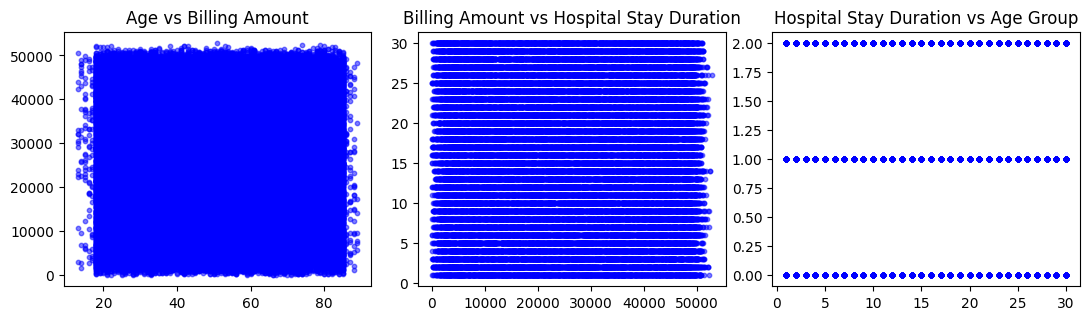

In [ ]:
# Scatterplots for Summarization
numeric_cols = ['Age', 'Billing Amount','Hospital Stay Duration','Age Group']

if len(numeric_cols) >= 2:
    plt.figure(figsize=(11, 6))

    sample_size = min(54966, len(df))
    df_sample = df.sample(sample_size) if len(df) > sample_size else df

    for i in range(min(6, len(numeric_cols)-1)):
        plt.subplot(2, 3, i+1)
        plt.scatter(
            df_sample[numeric_cols[i]],
            df_sample[numeric_cols[i+1]],
            alpha=0.5, 
            s=10,  
            c='blue'
        )
        plt.title(f'{numeric_cols[i]} vs {numeric_cols[i+1]}')

    plt.tight_layout()
    plt.savefig('scatterplot_summary.png', dpi=100)  # Lower DPI for faster saving
    plt.show()

In [ ]:
# PART 4: DATA DISCRETIZATION
print("\n DATA DISCRETIZATION FOR BILLING AMOUNT")
labels = ["Low-cost", "Medium-cost", "High-cost"]
num_bins_width = 3 
df['Billing_Amount_Equal_Width'], bins_width = pd.cut(df['Billing Amount'], bins=num_bins_width, labels=labels, retbins=True)
num_bins_freq = 3 
df['Billing_Amount_Equal_Freq'], bins_freq = pd.qcut(df['Billing Amount'], q=num_bins_freq, labels=labels, retbins=True)

#  results
print(df[['Billing Amount', 'Billing_Amount_Equal_Width', 'Billing_Amount_Equal_Freq']].head())



==== DATA DISCRETIZATION FOR BILLING AMOUNT ====
   Billing Amount Billing_Amount_Equal_Width Billing_Amount_Equal_Freq
0         18856.0                Medium-cost               Medium-cost
1         33643.0                Medium-cost               Medium-cost
2         27955.0                Medium-cost               Medium-cost
3         37910.0                  High-cost                 High-cost
4         14238.0                   Low-cost                  Low-cost


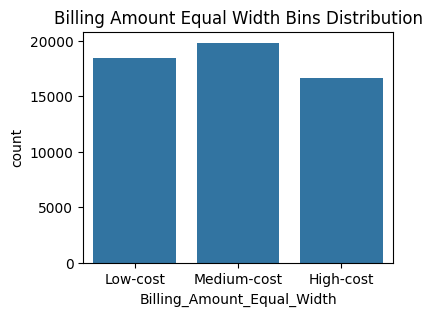

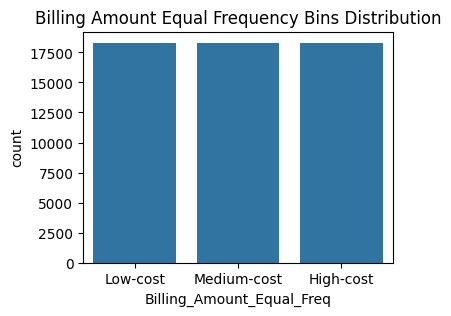

In [86]:
# Visualization
plt.figure(figsize=(4, 3))
sns.countplot(x=df["Billing_Amount_Equal_Width"])
plt.title("Billing Amount Equal Width Bins Distribution")
plt.show()

plt.figure(figsize=(4, 3))
sns.countplot(x=df["Billing_Amount_Equal_Freq"])
plt.title("Billing Amount Equal Frequency Bins Distribution")
plt.show()


Correlation Matrix:
 [[ 1.00000000e+00 -3.30600689e-03 -3.51804199e-04  7.88962949e-03
   8.65515683e-01]
 [-3.30600689e-03  1.00000000e+00 -3.71178760e-03 -4.79620075e-03
  -3.48479777e-03]
 [-3.51804199e-04 -3.71178760e-03  1.00000000e+00 -4.53961095e-03
   3.02318052e-03]
 [ 7.88962949e-03 -4.79620075e-03 -4.53961095e-03  1.00000000e+00
   8.76753694e-03]
 [ 8.65515683e-01 -3.48479777e-03  3.02318052e-03  8.76753694e-03
   1.00000000e+00]]


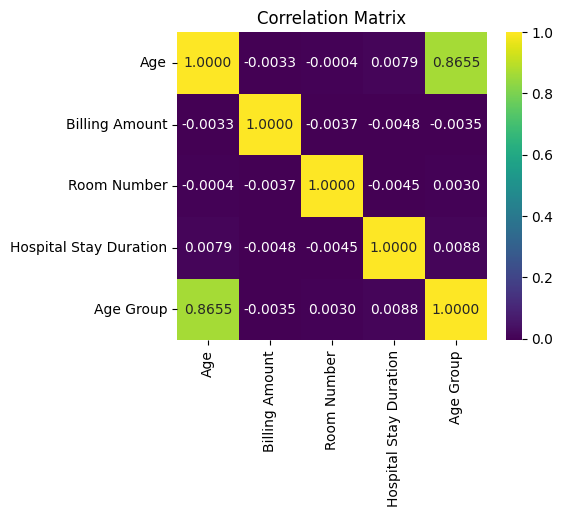

In [ ]:
# PART 5: Dimensionality Reduction
features = ['Age', 'Billing Amount', 'Room Number','Hospital Stay Duration','Age Group']
tensor_data = torch.tensor(df[features].values, dtype=torch.float32)
numpy_data = tensor_data.numpy()
corr_matrix = np.corrcoef(numpy_data.T)  

print("Correlation Matrix:\n", corr_matrix)

# Plot correlation matrix 
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".4f", xticklabels=features, yticklabels=features)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
import torch
import pandas as pd
import numpy as np

#  numeric features
numeric_features = ['Age', 'Billing Amount', 'Room Number', 'Hospital Stay Duration', 'Age Group']
data_tensor = torch.tensor(df[numeric_features].values, dtype=torch.float32)
data_tensor_standardized = (data_tensor - data_tensor.mean(dim=0)) / data_tensor.std(dim=0)
U, S, V = torch.svd(data_tensor_standardized)

pca_components = V[:, :2].T.numpy()

# DataFrame for PCA Loadings
component_df = pd.DataFrame(pca_components, columns=numeric_features, index=['PC1', 'PC2'])
importance_df = pd.DataFrame({'Feature': numeric_features, 'Importance': np.abs(pca_components).sum(axis=0)})

#  results
print("Component Loadings:\n", component_df)
print("\nFeature Importance (Lowest Can Be Dropped):\n", importance_df.sort_values('Importance'))


Component Loadings:
           Age  Billing Amount  Room Number  Hospital Stay Duration  Age Group
PC1  0.707025       -0.005631     0.002134                0.013624   0.707032
PC2 -0.008685       -0.478864    -0.378054                0.792214  -0.009253

Feature Importance (Lowest Can Be Dropped):
                   Feature  Importance
2             Room Number    0.380188
1          Billing Amount    0.484495
0                     Age    0.715710
4               Age Group    0.716285
3  Hospital Stay Duration    0.805838


In [ ]:
data_tensor = torch.cat((data_tensor[:, 0:2], data_tensor[:, 3:]), dim=1)
print(data_tensor)

tensor([[3.0000e+01, 1.8856e+04, 2.0000e+00, 1.0000e+00],
        [6.2000e+01, 3.3643e+04, 6.0000e+00, 2.0000e+00],
        [7.6000e+01, 2.7955e+04, 1.5000e+01, 2.0000e+00],
        ...,
        [3.8000e+01, 2.7621e+04, 2.8000e+01, 1.0000e+00],
        [4.3000e+01, 3.2451e+04, 6.0000e+00, 1.0000e+00],
        [5.3000e+01, 4.0100e+03, 2.7000e+01, 2.0000e+00]])


In [ ]:
updated_features = ['Age', 'Billing Amount', 'Hospital Stay Duration', 'Age Group']

# Convert back to DataFrame
df_updated = pd.DataFrame(data_tensor.numpy(), columns=updated_features)

print("Updated Dataset After Removing 'Room Number':\n", df_updated.head())
print("Updated Dataset Shape:", df_updated.shape)

Updated Dataset After Removing 'Room Number':
     Age  Billing Amount  Hospital Stay Duration  Age Group
0  30.0         18856.0                     2.0        1.0
1  62.0         33643.0                     6.0        2.0
2  76.0         27955.0                    15.0        2.0
3  28.0         37910.0                    30.0        1.0
4  43.0         14238.0                    20.0        1.0
Updated Dataset Shape: (54966, 4)


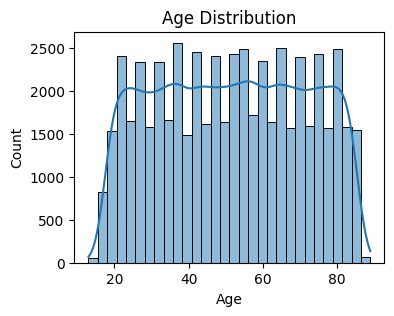

In [ ]:
# PART 6: Data Visualization
plt.figure(figsize=(4, 3))
sns.histplot(df_updated["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

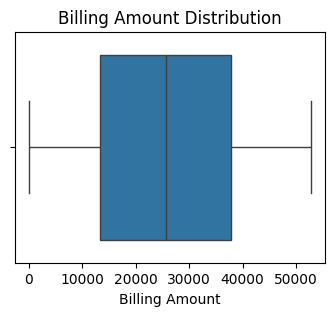

In [40]:
# Billing Amount Distribution - Identify extreme billing amounts
plt.figure(figsize=(4, 3))
sns.boxplot(x=df_updated["Billing Amount"])
plt.title("Billing Amount Distribution")
plt.show()


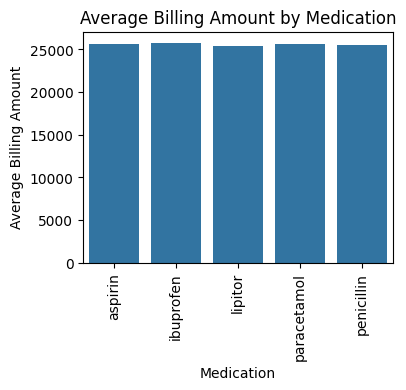

In [ ]:
# Medication vs Billing Amount
medication_billing = df.groupby("Medication")["Billing Amount"].mean().reset_index()
plt.figure(figsize=(4, 3))
sns.barplot(x="Medication", y="Billing Amount", data=medication_billing)
plt.xticks(rotation=90)
plt.title("Average Billing Amount by Medication")
plt.xlabel("Medication")
plt.ylabel("Average Billing Amount")
plt.show()

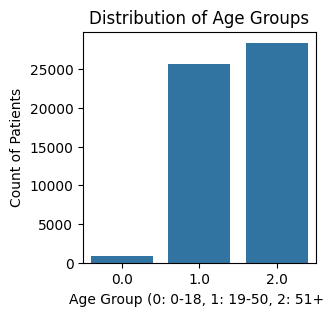

In [ ]:
# Age Group Distribution 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
sns.countplot(x=df_updated["Age Group"])
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group (0: 0-18, 1: 19-50, 2: 51+)")
plt.ylabel("Count of Patients")
plt.show()
